In [48]:
include(joinpath(@__DIR__, "..", "readclassjson.jl"))
using LinearAlgebra
using Plots

In [49]:
data = readclassjson("linexp_data.json")
Y = data["Y"]
n = Y.size[1]
N = Y.size[2]

y_sum = zeros(n)
for i in 1:N
    y_sum += Y[:,i]
end
b_star = y_sum / N

Y_tilda = Y
for i in 1:N
    Y_tilda[:,i] -= b_star
end
U, S, V = svd(Y_tilda)
display(S)

10-element Vector{Float64}:
 6.179456198341516
 1.8450964945273731
 1.0225601352248006
 0.04343823614029241
 0.013118447068711802
 0.01140377790701991
 0.00836897750145342
 0.006044613271087163
 0.004746882253536652
 0.002149692998152854

### Choose m = 3

In [50]:
m = 3

Um = U[:,1:m]
Sm = diagm(S[1:m])
Vm = V[:,1:m]

A_star = Um * Sm / sqrt(N)
X_star = sqrt(N) * Vm'
println("A* = ")
display(A_star)
println("b* = ")
display(b_star)
println("[x1, ..., xN] = ")
show(IOContext(stdout, :limit => false), MIME"text/plain"(), X_star)

A* = 


10×3 Matrix{Float64}:
 -0.229779   -0.0319414  -0.00165611
 -0.297116   -0.044084   -0.0492819
 -0.130048    0.0437469  -0.0136015
 -0.271295    0.0644646  -0.00780255
 -0.0781643   0.08584     0.00726946
 -0.15121    -0.0208137   0.0414588
 -0.161404    0.0100593   0.0525043
 -0.180124    0.0887402  -0.00420099
 -0.137342   -0.0617783  -0.0357625
 -0.209605   -0.0735962   0.0442039

b* = 


10-element Vector{Float64}:
 0.06294997889999998
 0.08114944870000004
 0.05105599600000002
 0.10051232249999995
 0.04574125690000003
 0.041098775200000014
 0.05247154449999998
 0.078772648
 0.027336755900000002
 0.04599555429999995

[x1, ..., xN] = 
3×100 Matrix{Float64}:
 -3.05646   -3.07893   -3.06096   -3.05218   -2.75966   -2.81316  -2.88402   -3.12326   -3.11146  -2.90734   0.404011   0.483642   0.065863  0.420781  0.468077   0.158608   0.348581    0.338107   0.317261   0.179532  0.432352    0.360233  0.347456   0.39003    0.316597   0.181377   0.217922   0.343375  0.383645   0.248245   0.290565   0.447365   0.434755   0.446067   0.299223  0.412424   0.221038   0.236844   0.317804     0.211543   0.439623   0.437594   0.345789   0.195153   0.304378   0.262926    0.431973  0.480793   0.419893  0.412084  0.385745  0.360246   0.463248   0.310709   0.214886  0.428282  0.46433   0.419174   0.25508   0.193392   0.328267   0.315093  0.39005   0.446829   0.276776   0.394097   0.360733   0.383153   0.208554   0.480823  0.348359    0.29742   0.279844   0.447626   0.159495  0.546062   0.305434  0.470065    0.186029  0.388982   0.329081   0.267698   0.308221   0.165837   0.417419  0.395879   0.222986   0.185909   0.254898

### Norm of error vector

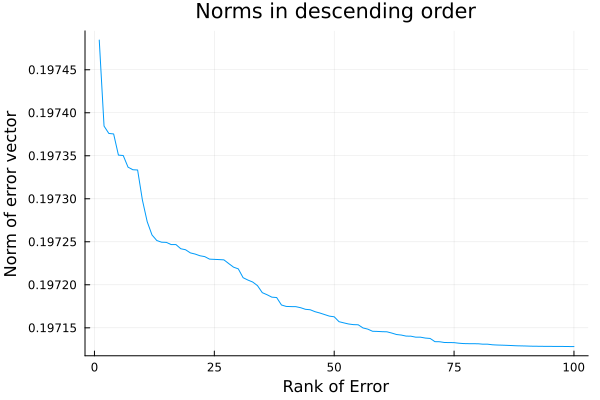

In [58]:
norm_e = zeros(N)
for i in 1:N
    norm_e[i] = norm(Y[:,i] - A_star * X_star[:, i] - b_star)
end

norm_e_sorted = sort(norm_e, rev = true)


plot(1:N, norm_e_sorted, xlabel="Rank of Error", 
ylabel="Norm of error vector", title="Norms in descending order", legend=false)

### Verification

In [52]:
X_star_sum = zeros(X_star.size[1])
for i in 1:N
    X_star_sum += X_star[:,i]
end
mean_x = X_star_sum / N
println("Mean of x (should be zero vector): $mean_x")

unitCov = X_star * X_star' / N
println("Unit sample covariance (should be m x m identity matrix):")
display(unitCov)

Mean of x (should be zero vector): [-1.1934897514720432e-16, -9.775166787129308e-17, 2.353672812205332e-16]
Unit sample covariance (should be m x m identity matrix):


3×3 Matrix{Float64}:
  1.0          1.05061e-16  -6.82112e-17
  1.05061e-16  1.0           3.92045e-16
 -6.82112e-17  3.92045e-16   1.0